In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
df = pd.read_csv('housing_price_dataset.csv')

In [26]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [28]:
df.describe()


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [29]:
df.shape

(50000, 6)

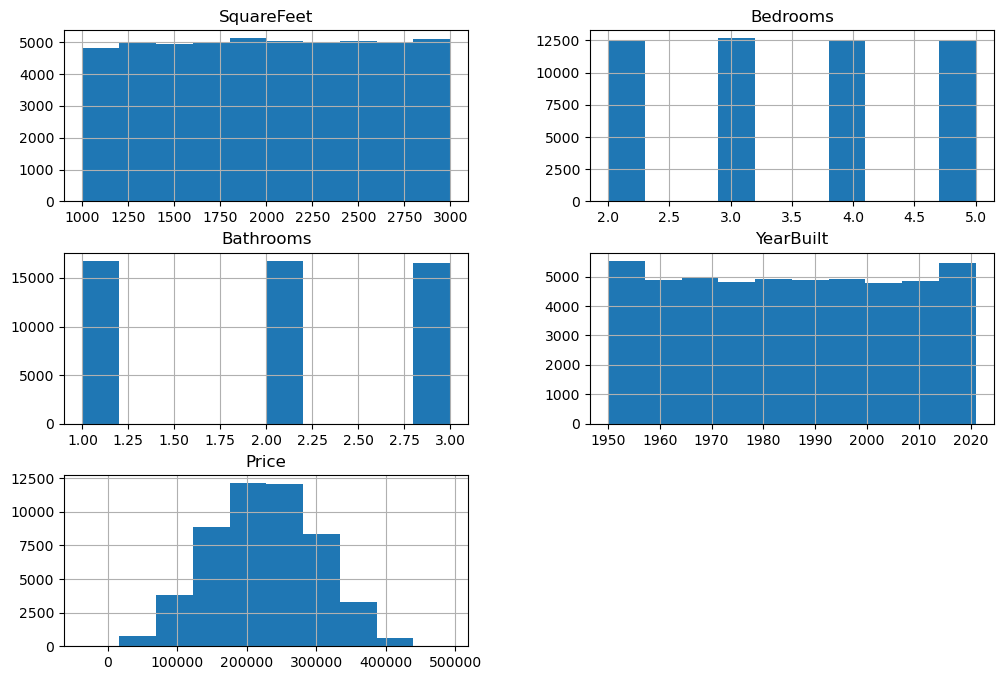

In [30]:
# Numerical features distribution
num_cols = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price']
df[num_cols].hist(figsize=(12, 8))
plt.show()

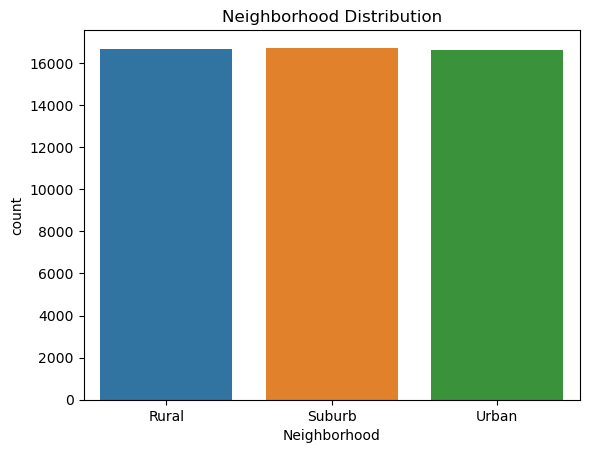

In [31]:
# Categorical feature distribution
sns.countplot(data=df, x='Neighborhood')
plt.title('Neighborhood Distribution')
plt.show()

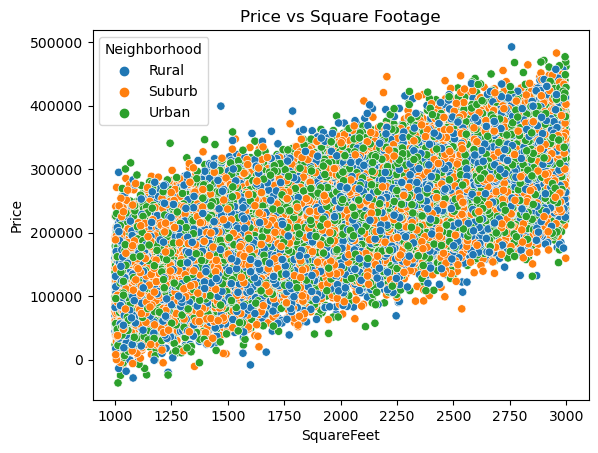

In [32]:
# Price vs SquareFeet
sns.scatterplot(data=df, x='SquareFeet', y='Price', hue='Neighborhood')
plt.title('Price vs Square Footage')
plt.show()


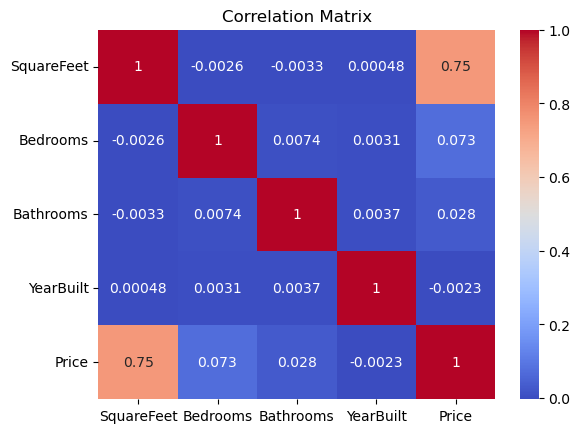

In [33]:
# Correlation matrix
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Key Observations:

##### 1. SquareFeet has the highest correlation with Price (0.75)

##### 2. YearBuilt has the lowest correlation with Price 

In [34]:
X = df.drop('Price', axis=1)
y = df['Price']

In [35]:
numeric_features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']
categorical_features = ['Neighborhood']

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [39]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SquareFeet', 'Bedrooms',
                                                   'Bathrooms', 'YearBuilt']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Neighborhood'])])),
                ('regressor', LinearRegression())])

In [40]:
# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [41]:
# Metrics
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Train R²: 0.5688921898995294
Test R²: 0.5755628630306235
Train MAE: 40014.792680074104
Test MAE: 39430.16533829791
Train RMSE: 50055.25278997792
Test RMSE: 49358.376911191546


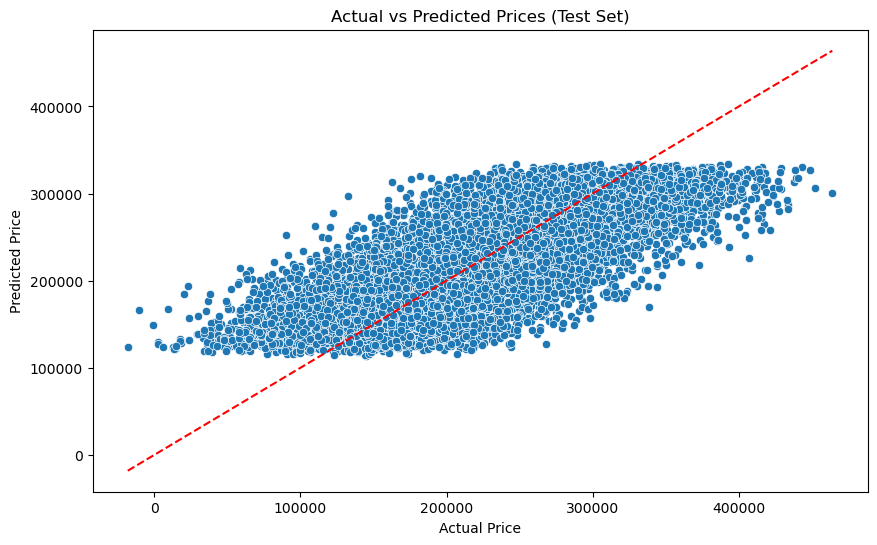

In [42]:
# Plot predictions vs actual (Test set)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Test Set)')
plt.show()